In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def parse_natality(natalitydata, datadictionary):
    '''Take in pandas dataframe natalitydata and list-of-lists datadictionary
    (for example [[43, 44, "MATERNALAGE"]] ) and return a pandas dataframe (same 
    number of rows) with labeled columns  '''
    df = pd.DataFrame()
    for start, stop, column_name in datadictionary:
        # Get the first column (start)
        df[column_name] = natalitydata[0].str.get(start-1)
        # Get the remaining columns
        for i in range(1, stop-start + 1):
            df[column_name]=  df[column_name].str.cat(natalitydata[0].str.get(start-1+i))
    return df
    for start, stop, column_name in datadictionary:
        pd[column_name] = pd.to_numeric(pd[column_name])

In [4]:
# https://www.cdc.gov/nchs/data_access/vitalstatsonline.htm 
# This notebook uses Nat1988.txt which is about 810 Mb.
# https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/DVS/natality/Nat1988.zip 

# Read the large (215 x 3.9million cells) data file into a pandas frame 
n1988 = pd.read_csv("~/Desktop/227/NATL1988.txt", header=None)

In [5]:
# Load in a file of three columns into a list of lists, the first two elements of which are integers.
# This is our table of column positions and column names
key1988 = []
for line in open("KEY1988.txt"):
    fields = line.strip().split()
    key1988.append([int(fields[0]), int(fields[1]), fields[2]])
key1988
# I really thought vaginal/caesarian birth "mode of delivery" would be in here but I can't find it in 1988.

[[12, 12, 'RESIDENTSTATUS'],
 [13, 14, 'STATEOFRESIDENCE'],
 [21, 21, 'POPULATIONSIZECITY'],
 [35, 35, 'SEX'],
 [36, 36, 'ATTENDANTTYPE'],
 [37, 37, 'RACEOFFATHER'],
 [38, 38, 'RACEOFMOTHER'],
 [39, 39, 'RACEOFCHILD'],
 [40, 40, 'RACEOFCHILDRECODE3'],
 [41, 42, 'AGEOFMOTHER'],
 [60, 60, 'BIRTHORDERRECODE9'],
 [69, 70, 'AGEOFFATHER'],
 [77, 78, 'BIRTHWEIGHTRECODE12'],
 [80, 80, 'PLACEOFDELIVERY'],
 [81, 81, 'PLURALITY'],
 [84, 85, 'MONTH'],
 [86, 87, 'DAY'],
 [93, 94, 'DETAILGESTATIONAGE'],
 [98, 99, 'MOTHERSEDUCATION'],
 [103, 104, 'FATHERSEDUCATION'],
 [107, 107, 'DETAILMARITALSTATUS'],
 [181, 182, 'ONEMINUTEAPGAR'],
 [184, 185, 'FIVEMINUTEAPGAR'],
 [187, 188, 'HISPANICMOTHER'],
 [189, 190, 'HISPANICFATHER']]

In [6]:
n1988 = pd.read_csv("~/Desktop/227/NATL1988.txt", header=None)

In [7]:
df = parse_natality(n1988, key1988)  # Takes 12 minutes 
df.head()

,RESIDENTSTATUS,STATEOFRESIDENCE,POPULATIONSIZECITY,SEX,ATTENDANTTYPE,RACEOFFATHER,RACEOFMOTHER,RACEOFCHILD,RACEOFCHILDRECODE3,AGEOFMOTHER,...,MONTH,DAY,DETAILGESTATIONAGE,MOTHERSEDUCATION,FATHERSEDUCATION,DETAILMARITALSTATUS,ONEMINUTEAPGAR,FIVEMINUTEAPGAR,HISPANICMOTHER,HISPANICFATHER
0,1,01,9,2,1,1,1,1,1,23,...,01,08,42,12,11,1,09,10,00,00
1,1,01,9,2,1,9,2,2,3,16,...,01,01,39,10,99,2,08,09,00,99
2,1,01,9,2,1,2,2,2,3,24,...,01,07,39,12,10,1,07,08,00,00
3,1,01,9,1,1,9,2,2,3,24,...,01,06,42,11,99,2,09,09,00,99
4,1,01,9,2,1,9,2,2,3,26,...,01,01,35,12,99,2,08,09,00,99


In [8]:
df["ONEMINUTEAPGAR"].value_counts()

ONEMINUTEAPGAR
09    1225724
08    1179788
99     926902
07     284030
06     102709
05      57629
04      36892
10      32464
03      25401
01      19762
02      19665
00       2827
Name: count, dtype: int64

(array([     0.,  50000., 100000., 150000., 200000., 250000., 300000.,
        350000., 400000., 450000.]),
 [Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000'),
  Text(0, 200000.0, '200000'),
  Text(0, 250000.0, '250000'),
  Text(0, 300000.0, '300000'),
  Text(0, 350000.0, '350000'),
  Text(0, 400000.0, '400000'),
  Text(0, 450000.0, '450000')])

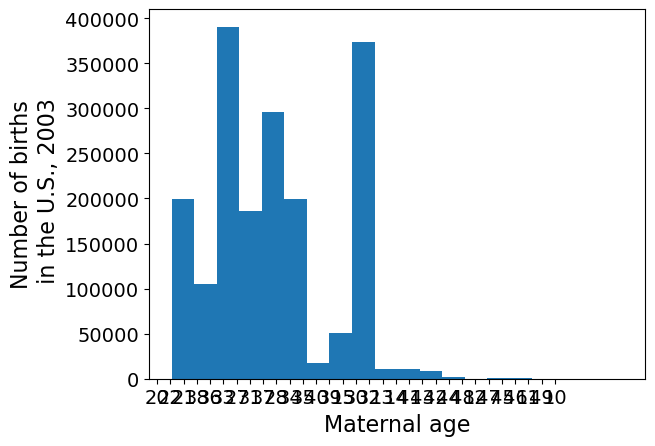

In [9]:
plt.hist(df["AGEOFMOTHER"], bins=np.arange(10,45,1.7)+.1)
plt.xlabel("Maternal age", fontsize=16)
plt.ylabel("Number of births\n in the U.S., 2003", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

This is totally unacceptable.  The maternal age labels are out of order and are not legible because they have been treated as nominal labels (not numerical labels).  

(array([1.99385e+05, 3.65450e+04, 6.81120e+04, 1.34290e+05, 2.56243e+05,
        1.85984e+05, 5.09070e+04, 2.45423e+05, 1.10971e+05, 8.86250e+04,
        1.74910e+04, 2.56570e+04, 2.56110e+04, 2.12852e+05, 1.60421e+05,
        1.80400e+03, 8.51100e+03, 1.13050e+04, 3.12100e+03, 5.84500e+03,
        1.63900e+03, 8.80000e+01, 2.23000e+02, 1.37000e+02, 7.72000e+02,
        3.90000e+02, 3.60000e+01, 4.20000e+01, 1.50000e+01, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00]),
 array([10.1, 11.1, 12.1, 13.1, 14.1, 15.1, 16.1, 17.1, 18.1, 19.1, 20.1,
        21.1, 22.1, 23.1, 24.1, 25.1, 26.1, 27.1, 28.1, 29.1, 30.1, 31.1,
        32.1, 33.1, 34.1, 35.1, 36.1, 37.1, 38.1, 39.1, 40.1, 41.1, 42.1,
        43.1, 44.1]),
 <BarContainer object of 34 artists>)

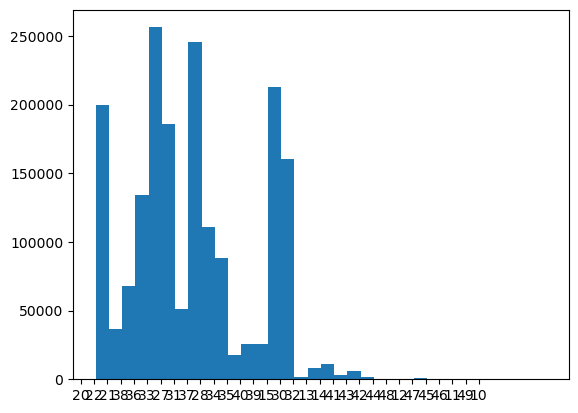

In [10]:
# How to fix... set the bins explicity? 
plt.hist(df["AGEOFMOTHER"], bins=np.arange(10,45,1)+.1)

In [12]:
# What's the data type here?  
df["AGEOFMOTHER"][0],  type(df["AGEOFMOTHER"][0])

('23', str)

In [13]:
# Convert AGEOFMOTHER to int
df["AGEOFMOTHER"] = df.AGEOFMOTHER.apply(int)

'23'

Text(0, 0.5, 'Number of US births in 1988')

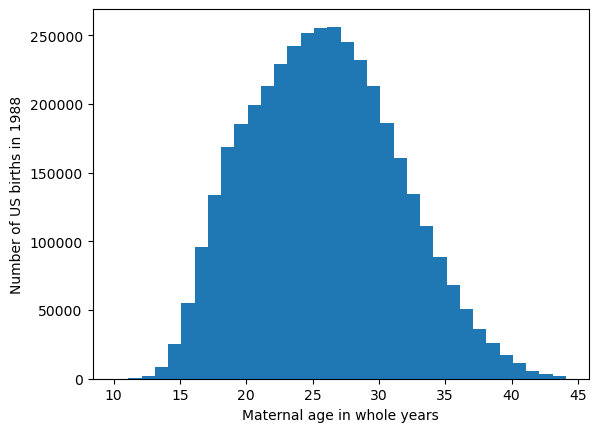

In [16]:
plt.hist(df["AGEOFMOTHER"], bins=np.arange(10,45,1)+.1)
plt.xlabel("Maternal age in whole years")
plt.ylabel("Number of US births in 1988")

Text(0.5, 1.0, 'Picket-fence histogram artifact')

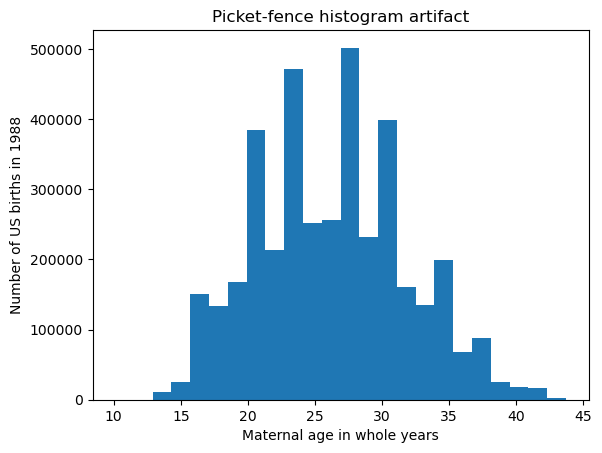

In [17]:
plt.hist(df["AGEOFMOTHER"], bins=np.arange(10,45,1.4)+.1)
plt.xlabel("Maternal age in whole years")
plt.ylabel("Number of US births in 1988")
plt.title("Picket-fence histogram artifact")

Text(0.5, 1.0, 'Picket-fence histogram artifact')

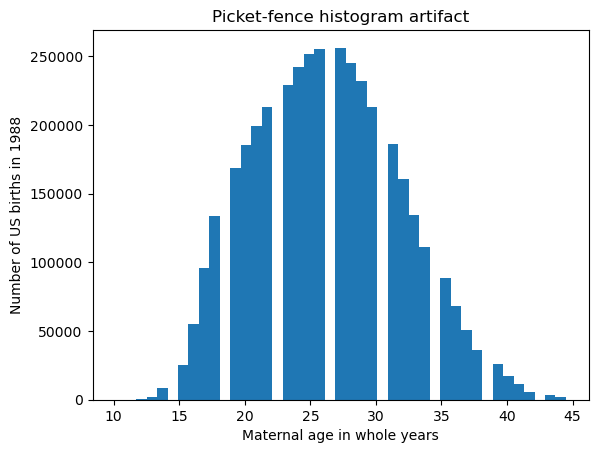

In [18]:
plt.hist(df["AGEOFMOTHER"], bins=np.arange(10,45,0.8)+.1)
plt.xlabel("Maternal age in whole years")
plt.ylabel("Number of US births in 1988")
plt.title("Picket-fence histogram artifact")

In [20]:
# Construct a table of fraction of babies at each Apgar score:
apgar1 = df["ONEMINUTEAPGAR"].value_counts().sort_index()/df.ONEMINUTEAPGAR.count()

<BarContainer object of 12 artists>

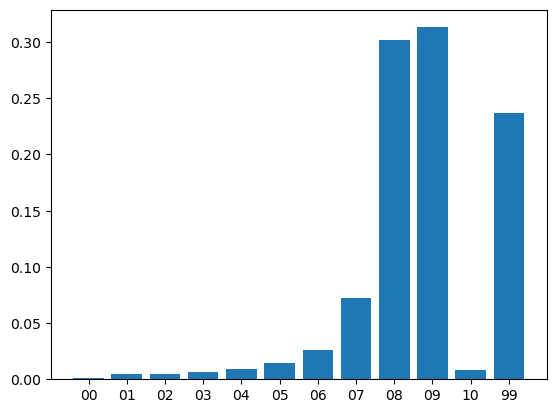

In [21]:
plt.bar(apgar1.index, apgar1)

In [22]:
apgar5 = df["FIVEMINUTEAPGAR"].value_counts().sort_index()/df.FIVEMINUTEAPGAR.count()

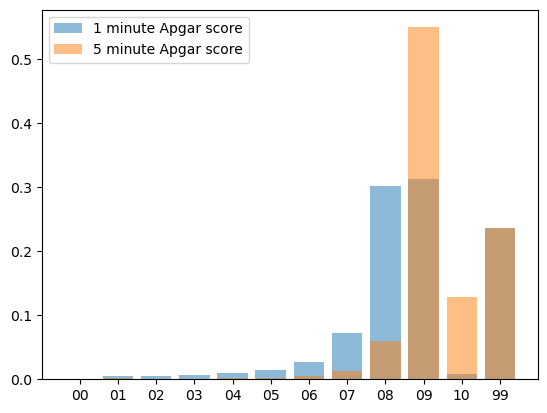

In [25]:
# Plot overlapping (transparent) histogram bars:
plt.bar(apgar1.index, apgar1, alpha=0.5, label="1 minute Apgar score")+plt.bar(apgar5.index, apgar5, alpha=0.5, label="5 minute Apgar score"); plt.legend()

In [31]:
apgar1.index == apgar5.index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [44]:
# So that I can fine-tune the x positions, 
apgar_index = np.array(apgar1.index).astype(int)
apgar_index

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 99])

In [47]:
# Aw, screw it, this isn't going to work.  Apgar scores 
# make more sense as labels than as numbers, but I need
# numbers to make fine adjustments to the x-axis.
apgar_index = np.array(range(len(apgar1.index)))

Text(0, 0.5, 'Fraction of 1988 births')

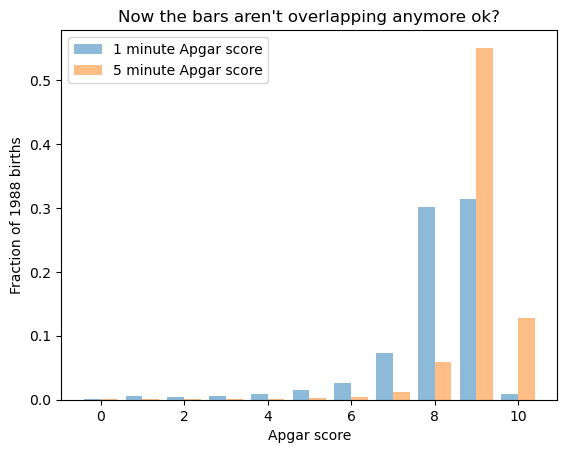

In [52]:
# From these two marginal distributions, we see that most babies perk up in the first few minutes of life:
# there are fewer 6,7,and 8 scores and more 9s and 10s.

# But we need not content ourselves with these marginal distributions; we have the full joint distribution.
# We can see what 1 minute scores change to in minute 5 if we wish.

# Let's get rid of the "99" missing data symbol

plt.bar(apgar_index[:-1]-0.2, apgar1[:-1], alpha=0.5, label="1 minute Apgar score", width=0.4)+plt.bar(
        apgar_index[:-1]+0.2, apgar5[:-1], alpha=0.5, label="5 minute Apgar score", width=0.4); plt.legend()
plt.title("Now the bars aren't overlapping anymore ok?")
plt.xlabel("Apgar score")
plt.ylabel("Fraction of 1988 births")

In [53]:
df.DAY.value_counts()

DAY
22    133094
08    132952
15    132883
29    131792
19    130720
28    130629
12    130094
18    130035
01    129940
20    129787
21    129716
07    129599
14    129524
16    129031
11    128938
26    128610
09    127886
27    127819
06    127817
25    127612
23    127370
02    126943
05    126746
04    125798
13    125315
17    125259
10    124794
03    123604
24    121460
30    116662
31     71357
99         7
Name: count, dtype: int64

In [54]:
df.DAY.value_counts().sort_index()

DAY
01    129940
02    126943
03    123604
04    125798
05    126746
06    127817
07    129599
08    132952
09    127886
10    124794
11    128938
12    130094
13    125315
14    129524
15    132883
16    129031
17    125259
18    130035
19    130720
20    129787
21    129716
22    133094
23    127370
24    121460
25    127612
26    128610
27    127819
28    130629
29    131792
30    116662
31     71357
99         7
Name: count, dtype: int64

<BarContainer object of 32 artists>

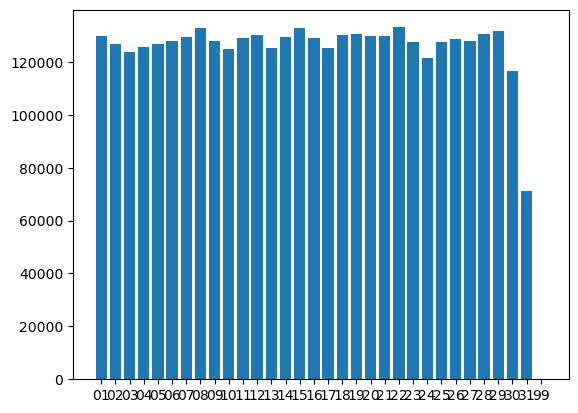

In [55]:
# I can turn this into a bar chart if I try:
plt.bar(df.DAY.value_counts().sort_index().index, df.DAY.value_counts().sort_index() )

In [56]:
# Please forgive the overplotting...
# The 30th only has 11 months, the 31st only has 7 months.

(<Figure size 1250x340 with 3 Axes>,
 array([<Axes: ylabel='2019'>, <Axes: ylabel='2020'>], dtype=object))

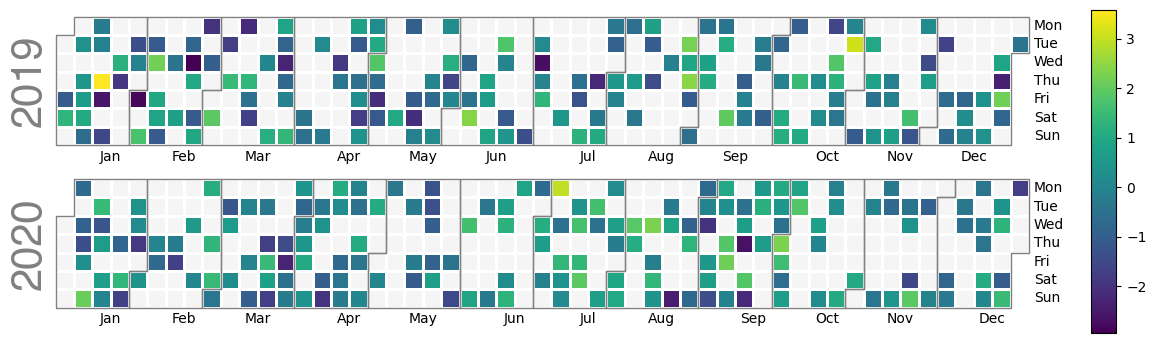

In [57]:
# This is the example code from a python module for making calendars:
# https://github.com/tomkwok/calplot
# This is a test run to make a calendar with random data.
import calplot
import numpy as np; np.random.seed(sum(map(ord, 'calplot')))
import pandas as pd
all_days = pd.date_range('1/1/2019', periods=730, freq='D')
days = np.random.choice(all_days, 500)
events = pd.Series(np.random.randn(len(days)), index=days)
calplot.calplot(events)

1988-03-28    0.113762
1988-12-21   -0.761130
1988-09-01    0.768522
1988-08-28    1.731792
1988-09-18   -0.666398
dtype: float64

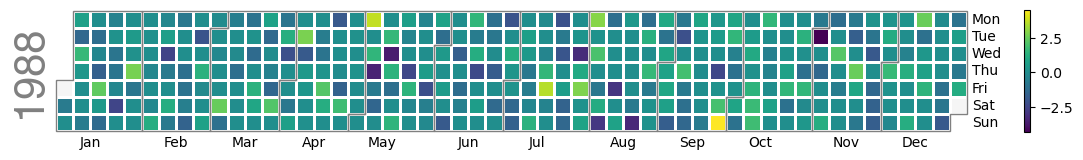

In [59]:
# Test calendar for 1988 with random data
all_days = pd.date_range('1/1/1988', periods=365, freq='D')
days = np.random.choice(all_days, 500)
events = pd.Series(np.random.randn(len(days)), index=days)
calplot.calplot(events)
events.head()

In [91]:
df["DATE"] = "1988" + df.MONTH + df.DAY

In [65]:
df.DATE.value_counts()

DATE
19880920    12851
19880707    12727
19880923    12694
19880909    12661
19880916    12620
            ...  
19880699        2
19880399        2
19881099        1
19880499        1
19880599        1
Name: count, Length: 371, dtype: int64

In [93]:
df["Date"] = pd.to_datetime(df.DATE)

ValueError: unconverted data remains when parsing with format "%Y%m%d": "9", at position 291. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [92]:
df["Date"] = pd.to_datetime(df.DATE, format="ISO8601")

ValueError: Time data 19881099 is not ISO8601 format, at position 291. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# The datetime parser is choking on some of the data.
# ValueError: Time data 19881099 is not ISO8601 format

In [74]:
# October 99th is not a suitable date.
# https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
# we have options errors="ignore" which will set the date to the input or
# errors="coerce" which will set the date to Not a Time.
df["DATE"] = pd.to_datetime("1988" + df["MONTH"]+ df["DAY"], errors="coerce")

In [75]:
len(df.DATE.value_counts())

366

In [76]:
df.DATE.value_counts()

DATE
1988-09-20    12851
1988-07-07    12727
1988-09-23    12694
1988-09-09    12661
1988-09-16    12620
              ...  
1988-03-13     8291
1988-01-03     8177
1988-04-03     8128
1988-01-02     8049
1988-12-25     7835
Name: count, Length: 366, dtype: int64

In [ ]:
# Oh.  1988 was 366 days long.  :)

In [77]:
datehist = df["DATE"].value_counts()
datehist.head()

DATE
1988-09-20    12851
1988-07-07    12727
1988-09-23    12694
1988-09-09    12661
1988-09-16    12620
Name: count, dtype: int64

Text(0.5, 0, 'Day in 1988 rank')

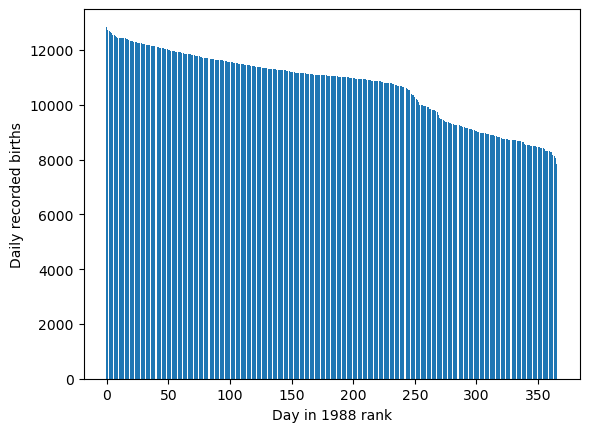

In [94]:
plt.bar(range(len(datehist)), datehist)
plt.ylabel("Daily recorded births")
plt.xlabel("Day in 1988 rank")

What is this?  This is the euqivalent of a cumulative distribution funciton with a shape like an eroding sand dune.  What does this mean?  This is the CDF of a bimodal distribution (!!)

(array([10., 39., 38., 16., 13., 27., 94., 62., 48., 19.]),
 array([ 7835. ,  8336.6,  8838.2,  9339.8,  9841.4, 10343. , 10844.6,
        11346.2, 11847.8, 12349.4, 12851. ]),
 <BarContainer object of 10 artists>)

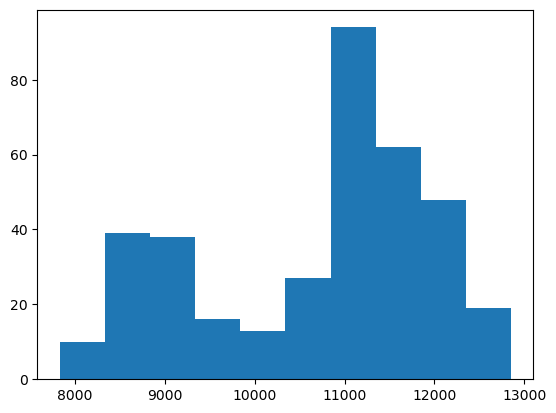

In [83]:
# Bear with me, let's take the histogram of the histogram.
# ?!?  This is the number of days as a function of daily 
# recorded birth rate.  
plt.hist(df["DATE"].value_counts().values)

Text(0.5, 0, 'Daily recorded births')

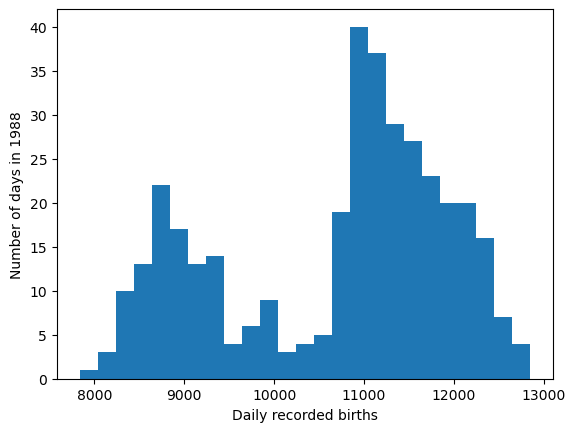

In [86]:
# We've got 366 days, we can afford more than 10 bins.
plt.hist(df["DATE"].value_counts().values, bins=25)
plt.ylabel("Number of days in 1988")
plt.xlabel("Daily recorded births")

In [87]:
datehist.head()

DATE
1988-09-20    12851
1988-07-07    12727
1988-09-23    12694
1988-09-09    12661
1988-09-16    12620
Name: count, dtype: int64

(<Figure size 1250x170 with 2 Axes>,
 array([<Axes: ylabel='1988'>], dtype=object))

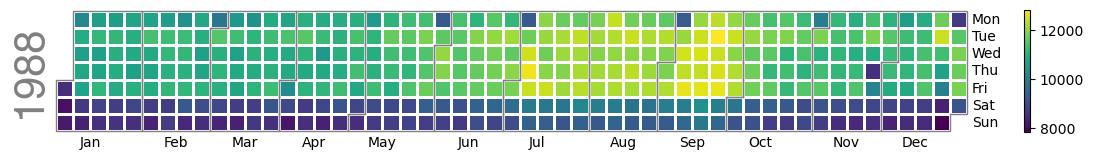

In [78]:
# This looks promising.  Let us try making a calendar plot.
calplot.calplot(datehist)
# Wow!

In [95]:
df.groupby("ONEMINUTEAPGAR")


In [96]:
# Ok, this gives me some pandas function that I can't work with directly...
df.groupby("ONEMINUTEAPGAR").count()

,RESIDENTSTATUS,STATEOFRESIDENCE,POPULATIONSIZECITY,SEX,ATTENDANTTYPE,RACEOFFATHER,RACEOFMOTHER,RACEOFCHILD,RACEOFCHILDRECODE3,AGEOFMOTHER,...,DAY,DETAILGESTATIONAGE,MOTHERSEDUCATION,FATHERSEDUCATION,DETAILMARITALSTATUS,FIVEMINUTEAPGAR,HISPANICMOTHER,HISPANICFATHER,DATE,Date
ONEMINUTEAPGAR,,,,,,,,,,,,,,,,,,,,,
00,2827,2827,2827,2827,2827,2827,2827,2827,2827,2827,...,2827,2827,2827,2827,2827,2827,2827,2827,2827,2827
01,19762,19762,19762,19762,19762,19762,19762,19762,19762,19762,...,19762,19762,19762,19762,19762,19762,19762,19762,19762,19762
02,19665,19665,19665,19665,19665,19665,19665,19665,19665,19665,...,19665,19665,19665,19665,19665,19665,19665,19665,19665,19665
03,25401,25401,25401,25401,25401,25401,25401,25401,25401,25401,...,25401,25401,25401,25401,25401,25401,25401,25401,25401,25401
04,36892,36892,36892,36892,36892,36892,36892,36892,36892,36892,...,36892,36892,36892,36892,36892,36892,36892,36892,36892,36892
05,57629,57629,57629,57629,57629,57629,57629,57629,57629,57629,...,57629,57629,57629,57629,57629,57629,57629,57629,57629,57629
06,102709,102709,102709,102709,102709,102709,102709,102709,102709,102709,...,102709,102709,102709,102709,102709,102709,102709,102709,102709,102709
07,284030,284030,284030,284030,284030,284030,284030,284030,284030,284030,...,284030,284030,284030,284030,284030,284030,284030,284030,284030,284029
08,1179788,1179788,1179788,1179788,1179788,1179788,1179788,1179788,1179788,1179788,...,1179788,1179788,1179788,1179788,1179788,1179788,1179788,1179788,1179788,1179785


In [98]:
# Oh, no, that's not right.  This counted the number of entries in all the columns.  I only want counts for one column
df.groupby("ONEMINUTEAPGAR").FIVEMINUTEAPGAR.count()

ONEMINUTEAPGAR
00       2827
01      19762
02      19665
03      25401
04      36892
05      57629
06     102709
07     284030
08    1179788
09    1225724
10      32464
99     926902
Name: FIVEMINUTEAPGAR, dtype: int64

In [99]:
# This is only one-dimensional.

# looks like I need to groupby both ONEMINUTEAPGAR and FIVEMINUTEAPGAR
apgarapgarhist = df.groupby(["ONEMINUTEAPGAR", "FIVEMINUTEAPGAR"]).FIVEMINUTEAPGAR.count()
apgarapgarhist.head()

ONEMINUTEAPGAR  FIVEMINUTEAPGAR
00              00                 1355
                01                  404
                02                  207
                03                  162
                04                  147
Name: FIVEMINUTEAPGAR, dtype: int64

In [100]:
# And this looks like the 2d histogram I seek.  

# To generate a heatmap, I'll convert to a numpy array 
apgarapgar= np.reshape(np.array(apgarapgarhist), (12,12))


In [101]:
# It is likely, but we should check, that ONEMINUTEAPGAR is indexed by row, FIVEMINUTEAPGAR by column
apgarapgar[0,1]  # should be 404 if row is ONEMINUTEAPGAR and column is FIVEMINUTEAPGAR

np.int64(404)

In [102]:
# chop off unknown apgar scores
apgarapgar = apgarapgar[0:11,0:11]

(Text(0, 0.5, 'One minute Apgar score'),
 Text(0.5, 0, 'Five minute Apgar score'))

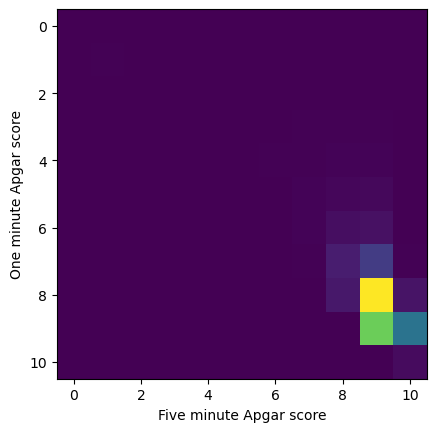

In [103]:
plt.imshow(apgarapgar); plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score")

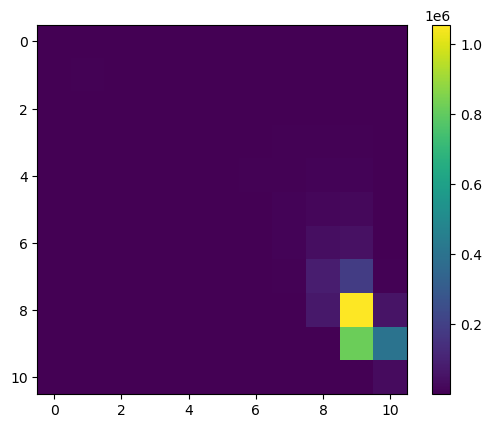

In [104]:
# There is almost no color in the bottom column, and there is color in the final row, consistent with
# the 1d histograms with <1% in apgar1 = 10 but ~14% in apgar5 = 10
# Need a colorbar
plt.imshow(apgarapgar); plt.colorbar()

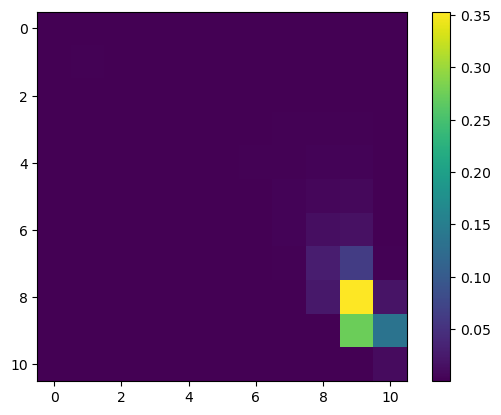

In [105]:
# Right.  Raw counts.  Divide by the total number of scores in this 11x11 submatrix..
plt.imshow(apgarapgar/apgarapgar.sum()); plt.colorbar()

In [ ]:
# and my, there isn't a lot of contrast here.  
#  Two reasonable options to enhance the contrast:  
#      Exaggerated colormap (log-scale colormap)
#      Divide by rows ; divide by columns to give the conditional distributions
#      of for example   AP5 | AP1 = 8  or AP1 | AP5 = 8
# Divide by column totals (apgar 5)  -- where did apgar 5 scores come from?
plt.imshow(apgarapgar/apgarapgar.sum(axis=0)); 
plt.ylabel("One minute Apgar score"), plt.xlabel("Given five minute Apgar score"); plt.colorbar()

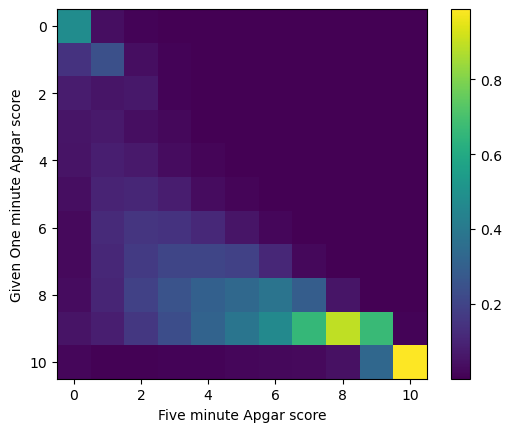

In [106]:
# divide by row totals -- where did apgar1 scores end up?
plt.imshow(apgarapgar.T/apgarapgar.T.sum(axis=0).T); 
plt.ylabel("Given One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()

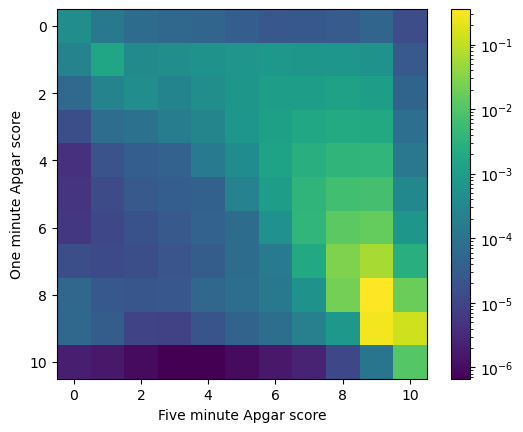

In [107]:
# And here is the exaggerated-color scale version
# Here matlab.colors.LogNorm  handles making the color scale logarithmic for us. 
from matplotlib.colors import LogNorm
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()

In [ ]:
# At least this one shows the truth that infants usually improve their scores between tests!

In [ ]:
# Exaggerated-color scale version
#  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
#  plt.savefig() claims to support PNG, EPS, PDF, and SVG
#  It stands to reason they have different optional arguments (resolution, quality, metadata)
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()
plt.savefig("APGAR.png")

In [ ]:
# Let us marginalize over output formats...
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()
plt.savefig("APGAR.jpg")
plt.figure()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()
plt.savefig("APGAR.pdf")
plt.figure()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()
plt.savefig("APGAR.eps")
plt.figure()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()
plt.savefig("APGAR.svg")

In [ ]:
plt.figure()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score"), plt.xlabel("Five minute Apgar score"); plt.colorbar()
plt.savefig("APGAR300.png", dpi=300)

In [ ]:
# And this seems to work, though at the cost of file size.   
# Make my fonts larger and I'll declare victory

plt.figure()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score", fontsize=15), plt.xlabel("Five minute Apgar score", fontsize=15); plt.colorbar()
plt.savefig("APGAR.eps")

In [ ]:
fig, ax = plt.subplots()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score", fontsize=15), plt.xlabel("Five minute Apgar score", fontsize=15); 
plt.xticks(fontsize=13); plt.yticks(fontsize=13)
#plt.colorbar(fontsize=13)
plt.savefig("APGAR.eps")

In [ ]:
fig, ax = plt.subplots()
plt.imshow((apgarapgar/apgarapgar.sum()), norm=LogNorm())
plt.ylabel("One minute Apgar score", fontsize=15), plt.xlabel("Five minute Apgar score", fontsize=15); 
plt.xticks(fontsize=13); plt.yticks(fontsize=13)
cb = plt.colorbar()
dir(cb)
cb.ax.tick_params(labelsize=13) 
plt.savefig("APGAR.eps")